In [125]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar, c, epsilon_0
import qutip as qt
from scipy.interpolate import interp1d
import scipy.special as sp
import pickle
from datetime import datetime

# Calculate maximum Intensity

In [126]:
def I_max_formula(E_pulse, w_beam, tau_fwhm):
    """Calculates the peak intensity from the pulse energy, the beam radius and the pulse duration (FWHM)"""
    tau_pulse = tau_fwhm / np.sqrt(2 * np.log(2))
    I_0 = (2 / np.pi)**(3/2) * E_pulse / (w_beam**2 * tau_pulse)
    return I_0

def pulse_energy(I_avg, rep_r, w_beam):
    """Calculates the pulse energy from the average intensity, the repetition rate and the beam radius"""
    P_avg = I_avg * np.pi * w_beam**2 / 2
    print(P_avg)
    E_pulse = P_avg / rep_r
    print(E_pulse)
    return E_pulse

def I_max_calc(I_avg, rep_r, w_beam, tau_fwhm):
    """Calculate the peak intensity from average intensity, the repetition rate, the beam radius and the pulse duration (FWHM)"""
    energy_per_pulse = pulse_energy(I_avg, rep_r, w_beam)
    I_max = I_max_formula(energy_per_pulse, w_beam, tau_fwhm)
    return I_max

In [127]:
Iavg = 1.1e8       # average intensity (at ion position) - from paper in W/m2
w = 30e-6          # beam waist in m - calculated from the expected diameter of the beam at the lens (30-40mm) and the length of the focal length of the lens (300mm)
taufwhm = 146e-15  # in s - as measured in the autocorrelation setup
reprate = 100000   # in Hz

I0 = I_max_calc(Iavg, reprate, w, taufwhm)
print("I0=", I0/1e12, "TW/m^2")

0.15550883635269477
1.5550883635269476e-06
I0= 7077.952099791892 TW/m^2


# Fourier transforms

General idea: 
1. Start with the full spectrum known from the measurements
2. Transform to time domain: there do the intensit normalization (as the intensities I have are for time domain & full specctrum)
3. Transform back to frequency domain: there do the cut in the spectrum
4. Transform back to time domain, as that is what I need in the end

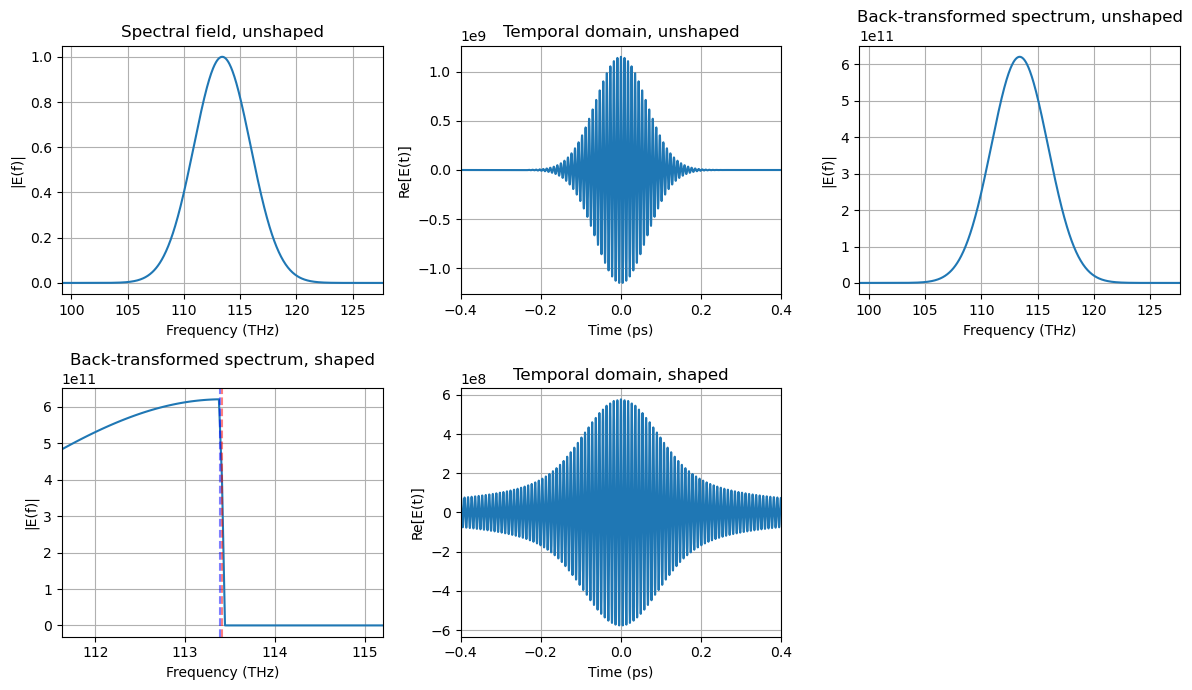

In [ ]:
# Parameters
omega0 = 712.5853879129392      # center frequency (angular) in THz (from the predicted wavenumber v=3783cm-1, see Zhenlin's paper)
f0 = omega0 / (2 * np.pi)       # center frequency (THz)
sigma_f = 1.783                 # spectral width (THz) (of power)
sigma_cut = 0.0342 / 4              # 0.0335 corresponds to 2nm resolution (10-90%), 0.0342 / 4 corresponds to the measured resolution
fshift = 0                      # shift of the cut with respect to the Q-branch transition

# Grid
f = np.linspace(-1200, 1200, 10**5)

# Corresponding time axis (ps)
t = np.fft.fftfreq(len(f), d=(f[1]-f[0]))   
indices_sort = np.argsort(t)
tsort = t[indices_sort]                

# Start with full spectrum in frequency domain
I_f_full = np.exp(-0.5 * ((f - f0) / sigma_f)**2)                               # Gaussian spectrum
E_f_full = np.sqrt(I_f_full)                                                    # E as square root of intensity. In principle there are more factors, but as the normalizatin happens later in the time domain, it doesn't matter here
# N_chop = len(E_f_full)                                                        (Codeleiche!?)
E_f_reordered_full = np.fft.ifftshift(E_f_full)                                 # Shift, so that ifft in the next step can take it (it needs a certain form)

# IFFT to time domain with full spectrum & normalize the spectrum there to the measured I0
E_t_full = np.fft.ifft(E_f_reordered_full)                                      # actual Fourier transform
E_t_full /= np.max(np.real(E_t_full))                                           # first normalize to 1, so that have a starting poit
E_t_full = E_t_full * np.sqrt(I0) * np.sqrt(1 / (2 * c * epsilon_0))            # then normalize to intensity value from Zhenlin's experiment (factor *2 not /2, because complex, not sin/cos)                        
E_tsort_full = E_t_full[indices_sort]                                           # sorting the time indices, so that plotting works properly

# FFT back to frequency domain & cut spectrum there
E_f_back = np.fft.fft(E_t_full)                                                 # FFT back to frequency domain
E_f_back_reordered = np.fft.fftshift(E_f_back)                                  # Shifting needed again
E_f_shaped = E_f_back_reordered * 0.5 * (1 + sp.erf(((f0 - fshift) - f) / (np.sqrt(2) * sigma_cut)))       # Cut the spectrum
E_f = E_f_shaped                           

# IFFT back to time domain do get actual stuff I want (electric field of the cut spectrum in time domain with correct normalization)
# N_chop = len(E_f_shaped)                                                      (Codeleiche!?)
E_f_reordered_shaped = np.fft.ifftshift(E_f_shaped)                             # Shifting needed again
E_t_shaped = np.fft.ifft(E_f_reordered_shaped)                                  # IFFT back to time domain
E_tsort_shaped = E_t_shaped[indices_sort]                                       # sorting time indices again, so that plotting works
E_t = E_t_shaped

# Plot
plt.figure(figsize=(12, 7))
plt.subplot(2, 3, 1)
plt.plot(f, np.abs(E_f_full))
plt.xlabel("Frequency (THz)")
plt.ylabel("|E(f)|")
plt.xlim([f0 - 8 * sigma_f, f0 + 8 * sigma_f])
plt.title("Spectral field, unshaped")
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(tsort, np.real(E_tsort_full))
plt.xlabel("Time (ps)")
plt.ylabel("Re[E(t)]")
plt.xlim([-0.4, 0.4])
plt.title("Temporal domain, unshaped")
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(f, np.abs(E_f_back_reordered))
plt.xlabel("Frequency (THz)")
plt.ylabel("|E(f)|")
plt.xlim([f0 - 8 * sigma_f, f0 + 8 * sigma_f])
plt.title("Back-transformed spectrum, unshaped")
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(f, np.abs(E_f_shaped))
plt.xlabel("Frequency (THz)")
plt.ylabel("|E(f)|")
plt.xlim([f0 - 8 * sigma_f, f0 + 8 * sigma_f])
plt.xlim([f0-sigma_f, f0+sigma_f])
plt.title("Back-transformed spectrum, shaped")
plt.axvline(x=f0, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=f0-0.022, color='blue', linestyle='--', alpha=0.5)
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(tsort, np.real(E_tsort_shaped))
plt.xlabel("Time (ps)")
plt.ylabel("Re[E(t)]")
plt.xlim([-0.4, 0.4])
plt.title("Temporal domain, shaped")
plt.grid(True)


plt.tight_layout()
plt.show()


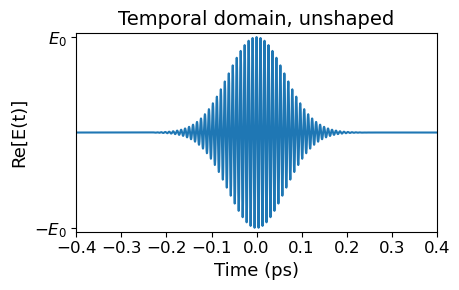

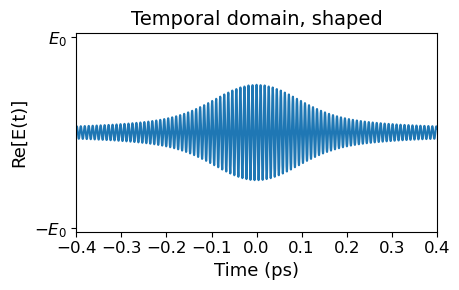

In [148]:
np.sqrt(I0) * np.sqrt(1 / (2 * c * epsilon_0))

yticks = [-np.sqrt(I0) * np.sqrt(1 / (2 * c * epsilon_0)), np.sqrt(I0) * np.sqrt(1 / (2 * c * epsilon_0))]
yticklabels = [r"$-E_0$", r"$E_0$"]

# just for plotting the time domain
plt.figure(figsize=(4.7, 3))
plt.plot(tsort, np.real(E_tsort_full))
plt.xlabel("Time (ps)", fontsize=13)
plt.ylabel("Re[E(t)]", fontsize=13)
plt.xlim([-0.4, 0.4])
plt.ylim([-1.2e9, 1.2e9])
plt.yticks(yticks, yticklabels, fontsize=12)
plt.xticks(fontsize=12)
plt.title("Temporal domain, unshaped", fontsize=14)
plt.tight_layout()
plt.savefig("plot_unshaped.pdf", format="pdf")

plt.figure(figsize=(4.7, 3))
plt.plot(tsort, np.real(E_tsort_shaped))
plt.xlabel("Time (ps)", fontsize=13)
plt.ylabel("Re[E(t)]", fontsize=13)
plt.xlim([-0.4, 0.4])
plt.ylim([-1.2e9, 1.2e9])
plt.yticks(yticks, yticklabels, fontsize=12)
plt.xticks(fontsize=12)
plt.title("Temporal domain, shaped", fontsize=14)
plt.tight_layout()
plt.savefig("plot_shaped.pdf", format="pdf")


plt.show()

In [149]:
# For later: make continuous function out of it
E_t_interp = interp1d(
    t,
    np.real(E_t),
    kind="linear",
    bounds_error=False,
    fill_value=0.0
)

def E_of_t(t, args):
    return float(E_t_interp(t))

E_t_interp05 = interp1d(
    t,
    np.real(np.sqrt(0.5) * E_t),
    kind="linear",
    bounds_error=False,
    fill_value=0.0
)

def E_of_t05(t, args):
    return float(E_t_interp05(t))

E_t_interp01 = interp1d(
    t,
    np.real(np.sqrt(0.1) * E_t),
    kind="linear",
    bounds_error=False,
    fill_value=0.0
)

def E_of_t01(t, args):
    return float(E_t_interp01(t))

# Time evolution

Solve the Schrödinger equation for the Hamiltonian $H = \frac{\Delta E}{2} \cdot \hat{\sigma}_z - d_0\cdot E(t) \cdot \hat{\sigma}_x$ for a single wavelength

In [150]:
# Pauli operators
sx = qt.sigmax()
sz = qt.sigmaz()

# Parameters
A = 353    # Einstein A coefficient (from Zhenlins simulations) in s**-1
d0_squared = A * 3 * np.pi * epsilon_0 * hbar * c**3 / (omega0 * 1e12)**3       # TRANSITION dipole moment. /hbar because Hamiltonian should be in angular frequency, not energy in the end. * 1.0e-12 because want in THz (as all the rest)
d0 = np.sqrt(d0_squared) /  hbar * 1.0e-12
print("d0 =", d0, "*1e12 m/(V*s)")
omega_test = omega0 - 1 * (2 * np.pi * 0.022)       # line position of the line I want to try (THz) (adding = R-branch, subtracting = P-branch)
print("omega_test =", omega_test)
DeltaE = omega_test                                 # in THz as sesolve takes (angular) frequencies, so don't have to change anything here

# Define Hamiltonian
H0 = 0.5 * DeltaE * sz                              # Molecule level Hamiltonian [THz]
H1 =  -d0 *  sx                                     # First part of interaction Hamiltonian (such that in complete, it will also be in [THz])
H = [H0, [H1,E_of_t]]                               # Complete Hamiltonian [THz]

# initial state: ground state
psi0 = qt.basis(2, 0) 

# numerical simulation options
options = {"atol": 1e-12, "nsteps": 10000}

# actual time evolution
result = qt.sesolve(H, psi0, tsort, options=options)                 # solve the Schrödinger equation (sesove takes angular frequencies, not energies for the Hamiltonian!)

d0 = 4.560735502951944e-09 *1e12 m/(V*s)
omega_test = 712.4471578361812


In [151]:
# Projection operators on ground/excited state
Pg = qt.basis(2,0) * qt.basis(2,0).dag()
Pe = qt.basis(2,1) * qt.basis(2,1).dag()

# Populations
pop_g = qt.expect(Pg, result.states)
pop_e = qt.expect(Pe, result.states)

Population in excited state in the beginning:  0.0 %
Population in excited state in the end:  5.355857136849996 %


Text(0, 0.5, 'Excitation in %')

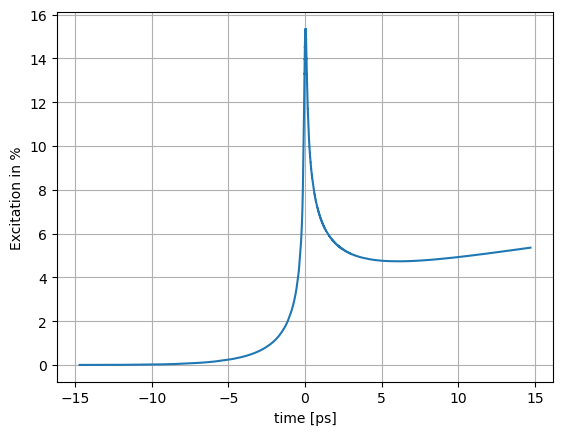

In [152]:
# plot the time evolution of excitation for the transition frequency chosen above (just for one transition)
print("Population in excited state in the beginning: ", pop_e[0] * 100, "%")
print("Population in excited state in the end: ", pop_e[-1] * 100, "%")
plt.plot(tsort, pop_e * 100)
plt.grid()
plt.xlabel("time [ps]")
plt.ylabel("Excitation in %")
#plt.xlim([-0.1, 0.1])

## Check the final excitation for multiple transitions (frequencies)

In [153]:
def omega_t(num):
    """
    Input: number of the transition line. Q-branch would be zero, P-branch transitions start counting from there in neg. direction, R-branches in pos. direction.
    Output: Angular frequency of the transition in THz
    """
    return(omega0 + num * (2 * np.pi * 0.022)) 

def get_Hamiltonian(omegat):
    """
    Input: transition frequency
    Output: Hamiltonian for that frequency
    """
    H0 = 0.5 * omegat * sz                  # Molecule level Hamiltonian [THz]
    H1 =  -d0 *  sx                         # First part of interaction Hamiltonian (such that in complete, it will also be in [THz])
    return([H0, [H1,E_of_t]])               # Complete Hamiltonian [THz]

def get_Hamiltonian05(omegat):
    """
    Input: transition frequency
    Output: Hamiltonian for that frequency
    """
    H0 = 0.5 * omegat * sz                  # Molecule level Hamiltonian [THz]
    H1 =  -d0 *  sx                         # First part of interaction Hamiltonian (such that in complete, it will also be in [THz])
    return([H0, [H1,E_of_t05]])               # Complete Hamiltonian [THz]

def get_Hamiltonian01(omegat):
    """
    Input: transition frequency
    Output: Hamiltonian for that frequency
    """
    H0 = 0.5 * omegat * sz                  # Molecule level Hamiltonian [THz]
    H1 =  -d0 *  sx                         # First part of interaction Hamiltonian (such that in complete, it will also be in [THz])
    return([H0, [H1,E_of_t01]])               # Complete Hamiltonian [THz]

def get_final_excitation(num):
    """
    Input: number of the transition line. Q-branch would be zero, P-branch transitions start counting from there in neg. direction, R-branches in pos. direction.
    Output: excitation at the end of the pulse
    """
    psi0 = qt.basis(2, 0)                   # ground state
    omegat = omega_t(num)                   # transition frequency 
    H = get_Hamiltonian(omegat)           
    res = qt.sesolve(H, psi0, tsort)
    pop_e = qt.expect(Pe, res.states)
    return pop_e[-1]

def get_final_excitation05(num):
    """
    Input: number of the transition line. Q-branch would be zero, P-branch transitions start counting from there in neg. direction, R-branches in pos. direction.
    Output: excitation at the end of the pulse
    """
    psi0 = qt.basis(2, 0)                   # ground state
    omegat = omega_t(num)                   # transition frequency 
    H = get_Hamiltonian05(omegat)           
    res = qt.sesolve(H, psi0, tsort)
    pop_e = qt.expect(Pe, res.states)
    return pop_e[-1]

def get_final_excitation01(num):
    """
    Input: number of the transition line. Q-branch would be zero, P-branch transitions start counting from there in neg. direction, R-branches in pos. direction.
    Output: excitation at the end of the pulse
    """
    psi0 = qt.basis(2, 0)                   # ground state
    omegat = omega_t(num)                   # transition frequency 
    H = get_Hamiltonian01(omegat)           
    res = qt.sesolve(H, psi0, tsort)
    pop_e = qt.expect(Pe, res.states)
    return pop_e[-1]

In [154]:
lines_set = np.linspace(-10, +10, 21)            # first and last line (in P-/R-branch spectrum) I want to calculate

fin_ex_list10 = []
for line in lines_set:
    ex = get_final_excitation(line)             # calculate the final excitation for every line
    fin_ex_list10.append(ex)                      # for checking the progress
    print(line)
print("Final excitations: ", fin_ex_list10)

fin_ex_list05 = []
for line in lines_set:
    ex = get_final_excitation05(line)             # calculate the final excitation for every line
    fin_ex_list05.append(ex)                      # for checking the progress
    print(line)
print("Final excitations: ", fin_ex_list05)

fin_ex_list01 = []
for line in lines_set:
    ex = get_final_excitation01(line)             # calculate the final excitation for every line
    fin_ex_list01.append(ex)                      # for checking the progress
    print(line)
print("Final excitations: ", fin_ex_list01)

-10.0
-9.0
-8.0
-7.0
-6.0
-5.0
-4.0
-3.0
-2.0
-1.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
Final excitations:  [0.15354477381949858, 0.15263412796551334, 0.15507420276278241, 0.1514268785440995, 0.1491922488175924, 0.15128256119009378, 0.14690275940928674, 0.14367356706312762, 0.12652917137166986, 0.05393698067663004, 0.0017314538396263617, 0.0027375770298890137, 0.0006333894500383035, 2.025331419178719e-05, 0.00041280131966390436, 0.0002518068579040553, 2.6428705835947383e-05, 0.00015441195407001182, 0.00013942956754429265, 2.030485009460707e-05, 7.559492262111425e-05]
-10.0
-9.0
-8.0
-7.0
-6.0
-5.0
-4.0
-3.0
-2.0
-1.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
Final excitations:  [0.08088586938380704, 0.0805600708916451, 0.08212639434851352, 0.08053952086162164, 0.07963553967637473, 0.08125764550798627, 0.0794636816798984, 0.07871263803553435, 0.07137827554832939, 0.03314409250552141, 0.002000346886568707, 0.0007308618127378666, 0.00012591201580429767, 7.480261598091804e-06, 8

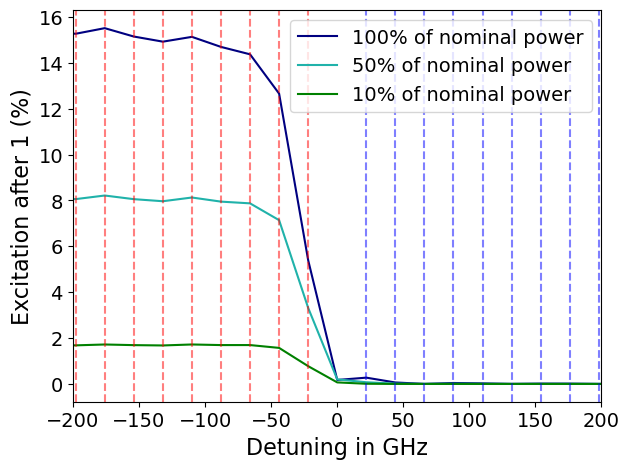

In [157]:
# Plot the results
plt.plot(lines_set * 22, [x * 100 for x in fin_ex_list10], label = "100% of nominal power", color='navy')
plt.plot(lines_set * 22, [x * 100 for x in fin_ex_list05], label = "50% of nominal power", color='lightseagreen')
plt.plot(lines_set * 22, [x * 100 for x in fin_ex_list01], label = "10% of nominal power", color='green')
for x in range(1, 11):                                                      # plot R-branch lines
    plt.axvline(x=x * 22, color='blue', linestyle='--', alpha=0.5)
for x in range(-10, 0):                                                     # plot P-branch lines
    plt.axvline(x=x * 22, color='red', linestyle='--', alpha=0.5) 
plt.xlabel("Detuning in GHz", fontsize=16)
plt.ylabel("Excitation after 1 (%)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="upper right", fontsize=14)
plt.xlim([-200, 200])
plt.tight_layout()
plt.savefig("onePulse.pdf", format="pdf")

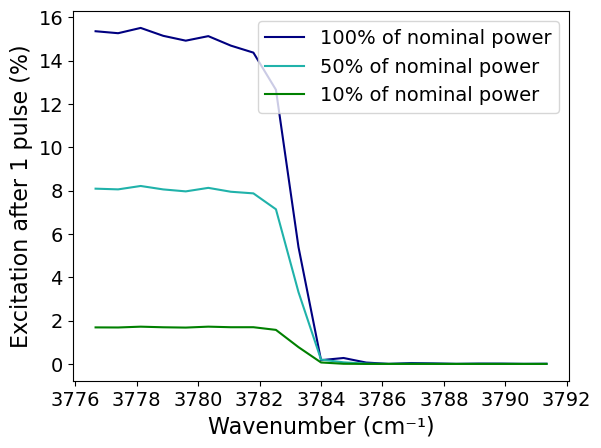

<Figure size 640x480 with 0 Axes>

In [156]:
# Plot over wavenumbers
# Conversion factor from GHz to cm^-1
GHz_to_cm1 = 1 / 29.9792458  # ~0.033356 cm^-1/GHz
central_wavenumber = 3784  # cm^-1

# Convert detuning to wavenumber axis
wavenumber_axis = central_wavenumber + (lines_set * 22) * GHz_to_cm1

# Plot the results
plt.plot(wavenumber_axis, [x * 100 for x in fin_ex_list10], label="100% of nominal power", color='navy')
plt.plot(wavenumber_axis, [x * 100 for x in fin_ex_list05], label="50% of nominal power", color='lightseagreen')
plt.plot(wavenumber_axis, [x * 100 for x in fin_ex_list01], label="10% of nominal power", color='green')

plt.xlabel("Wavenumber (cm⁻¹)", fontsize=16)
plt.ylabel("Excitation after 1 pulse (%)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="upper right", fontsize=14)
#plt.grid()
plt.show()
plt.tight_layout()
plt.savefig("onePulse_wavenumbers.pdf", format="pdf")


## Data collection for cooling simulation

In [ ]:
# for full power
lines_set = np.linspace(-70, +70, 141)            # first and last line (in P-/R-branch spectrum) I want to calculate
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename10 = f"fin_ex_list10_{timestamp}.pkl"
fin_ex_list10_data = []
for line in lines_set:
    ex = get_final_excitation(line)             # calculate the final excitation for every line
    fin_ex_list10_data.append(ex)                      # for checking the progress
    print(line)
with open(filename10, "wb") as f:
    pickle.dump(fin_ex_list10_data, f)
print("Final excitations: ", fin_ex_list10_data)

-70.0
-69.0
-68.0
-67.0
-66.0
-65.0
-64.0
-63.0
-62.0
-61.0
-60.0
-59.0
-58.0
-57.0
-56.0
-55.0
-54.0
-53.0
-52.0
-51.0
-50.0
-49.0
-48.0
-47.0
-46.0
-45.0
-44.0
-43.0
-42.0
-41.0
-40.0
-39.0
-38.0
-37.0
-36.0
-35.0
-34.0
-33.0
-32.0
-31.0
-30.0
-29.0
-28.0
-27.0
-26.0
-25.0
-24.0
-23.0
-22.0
-21.0
-20.0
-19.0
-18.0
-17.0
-16.0
-15.0
-14.0
-13.0
-12.0
-11.0
-10.0
-9.0
-8.0
-7.0
-6.0
-5.0
-4.0
-3.0
-2.0
-1.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
20.0
21.0
22.0
23.0
24.0
25.0
26.0
27.0
28.0
29.0
30.0
31.0
32.0
33.0
34.0
35.0
36.0
37.0
38.0
39.0
40.0
41.0
42.0
43.0
44.0
45.0
46.0
47.0
48.0
49.0
50.0
51.0
52.0
53.0
54.0
55.0
56.0
57.0
58.0
59.0
60.0
61.0
62.0
63.0
64.0
65.0
66.0
67.0
68.0
69.0
70.0
Final excitations:  [0.11229087159818493, 0.11343606865572117, 0.11459364095832426, 0.11573301864608339, 0.11689826001423126, 0.11799881238529775, 0.11911026105080806, 0.1202038417890816, 0.12133935373720277, 0.12242632724259112, 0.123580951948

In [ ]:
# for 50% of nominal power
lines_set = np.linspace(-70, +70, 141)            # first and last line (in P-/R-branch spectrum) I want to calculate
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename05 = f"fin_ex_list05_{timestamp}.pkl"
fin_ex_list05_data = []
for line in lines_set:
    ex = get_final_excitation05(line)             # calculate the final excitation for every line
    fin_ex_list05_data.append(ex)                      # for checking the progress
    print(line)
with open(filename05, "wb") as f:
    pickle.dump(fin_ex_list05_data, f)
print("Final excitations: ", fin_ex_list05_data)

-70.0
-69.0
-68.0
-67.0
-66.0
-65.0
-64.0
-63.0
-62.0
-61.0
-60.0
-59.0
-58.0
-57.0
-56.0
-55.0
-54.0
-53.0
-52.0
-51.0
-50.0
-49.0
-48.0
-47.0
-46.0
-45.0
-44.0
-43.0
-42.0
-41.0
-40.0
-39.0
-38.0
-37.0
-36.0
-35.0
-34.0
-33.0
-32.0
-31.0
-30.0
-29.0
-28.0
-27.0
-26.0
-25.0
-24.0
-23.0
-22.0
-21.0
-20.0
-19.0
-18.0
-17.0
-16.0
-15.0
-14.0
-13.0
-12.0
-11.0
-10.0
-9.0
-8.0
-7.0
-6.0
-5.0
-4.0
-3.0
-2.0
-1.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
20.0
21.0
22.0
23.0
24.0
25.0
26.0
27.0
28.0
29.0
30.0
31.0
32.0
33.0
34.0
35.0
36.0
37.0
38.0
39.0
40.0
41.0
42.0
43.0
44.0
45.0
46.0
47.0
48.0
49.0
50.0
51.0
52.0
53.0
54.0
55.0
56.0
57.0
58.0
59.0
60.0
61.0
62.0
63.0
64.0
65.0
66.0
67.0
68.0
69.0
70.0
Final excitations:  [0.05734828713571166, 0.057948568018337976, 0.05853877810722818, 0.059060272522861466, 0.05973447860415653, 0.06030080043584711, 0.060884652996109775, 0.06146499592593445, 0.06203294154063042, 0.06259258037275786, 0.06315210

In [108]:
# for 10% of nominal power
lines_set = np.linspace(-70, +70, 141)            # first and last line (in P-/R-branch spectrum) I want to calculate
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename01 = f"fin_ex_list01_{timestamp}.pkl"
fin_ex_list01_data = []
for line in lines_set:
    ex = get_final_excitation01(line)             # calculate the final excitation for every line
    fin_ex_list01_data.append(ex)                      # for checking the progress
    print(line)
with open(filename01, "wb") as f:
    pickle.dump(fin_ex_list01_data, f)
print("Final excitations: ", fin_ex_list01_data)

-70.0
-69.0
-68.0
-67.0
-66.0
-65.0
-64.0
-63.0
-62.0
-61.0
-60.0
-59.0
-58.0
-57.0
-56.0
-55.0
-54.0
-53.0
-52.0
-51.0
-50.0
-49.0
-48.0
-47.0
-46.0
-45.0
-44.0
-43.0
-42.0
-41.0
-40.0
-39.0
-38.0
-37.0
-36.0
-35.0
-34.0
-33.0
-32.0
-31.0
-30.0
-29.0
-28.0
-27.0
-26.0
-25.0
-24.0
-23.0
-22.0
-21.0
-20.0
-19.0
-18.0
-17.0
-16.0
-15.0
-14.0
-13.0
-12.0
-11.0
-10.0
-9.0
-8.0
-7.0
-6.0
-5.0
-4.0
-3.0
-2.0
-1.0
0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
20.0
21.0
22.0
23.0
24.0
25.0
26.0
27.0
28.0
29.0
30.0
31.0
32.0
33.0
34.0
35.0
36.0
37.0
38.0
39.0
40.0
41.0
42.0
43.0
44.0
45.0
46.0
47.0
48.0
49.0
50.0
51.0
52.0
53.0
54.0
55.0
56.0
57.0
58.0
59.0
60.0
61.0
62.0
63.0
64.0
65.0
66.0
67.0
68.0
69.0
70.0
Final excitations:  [0.011786983939813369, 0.011930783242303034, 0.012042032274055054, 0.012168505192191391, 0.012294693300523612, 0.01240625695023061, 0.012543793078308505, 0.012643155035027972, 0.012788090402405153, 0.012876878045750006, 0.01